In [1]:
import skimage as ski
import os
import matplotlib.pyplot as plt
import numpy as np

image_dir = os.path.normpath("C:/Users/heine/OneDrive - University College London\Microscope_data/20250912_mbx2_oe")

savefig_dir = os.path.normpath("G:/.shortcut-targets-by-id/0B3ejcGO9fA5eYXlHMW9tekVERmc/JB labs documents/Updated_JB_documents_2019/JB LAB_Projects/biofilm_qtl/data/microscope/20250912_mbx2_OE")


strain_ids = {('JB22','prADH1','GFP'): 'LS15',
              ('JB22','prENO1','GFP'): 'LS16',
              ('JB22','prNMT1','GFP'): 'LS13', 
              ('JB22','prNMT1','mbx2'): 'LS19', 
              ('JB22','prRPL2102','GFP'): 'LS14', 
              ('JB22','prRPL2102','mbx2'): 'LS20', 
              ('JB50','prADH1','GFP'): 'LS09',
              ('JB50','prENO1','GFP'): 'LS10',
              ('JB50','prNMT1','GFP'): None,  
              ('JB50','prNMT1','mbx2'): 'LS17', 
              ('JB50','prRPL2102','GFP'): 'LS08', 
              ('JB50','prRPL2102','mbx2'): 'LS18'
              }

In [2]:
#Protocol: 
#
#Choose and Organize TIFF Files 
#   Using Bioformat importer, import original images
#   Load with virtual stack and load metadata. 
#   Select one image to view and then you can access metadata.  Save metadata as <>_metadata.txt
#   Find the mapping for the image series to well with Information|Image|S|Scene|ArrayName
#   Prepare a spreadsheet mapping image scenes to strain / experiment information as YES_plate_mapping.xlsx
#   Using that sheet save raw GFP and bright field images with the appropriate filename.  First adjust image brightness/contrast to see the bright field channel.  Use  Use Image->Stacks->Tools->Make Substack to pick the correct Z dimension for both channels and save as .tif using the appropriate filename.


# Note:  I always seem to see the first slice as in focus - I would prefer for the middle slice to be in focus. 

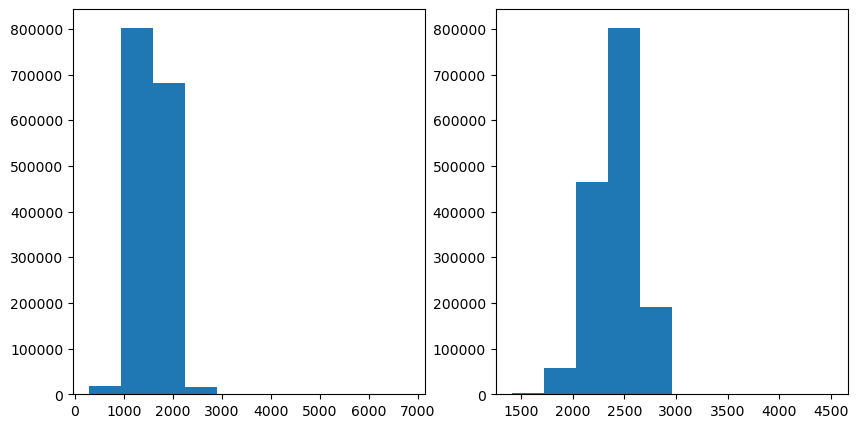

In [3]:
#Using histograms to determine cutoff for visualization in each channel

media = 'YES'
background = 'JB22'
promoter = 'prNMT1'
oe_gene = "GFP"
strain_id = "LS13"

#image_series, Z = image_choice_lookup[(strain,medium)]


                
img_fname = image_dir + os.sep + os.path.normpath('YES_plate_tiff_images/' + background + '_' + promoter + '_' + oe_gene + '_' + strain_id + '_BR1_TR1.tif')
img = ski.io.imread(img_fname)

img_bf = img[0,:,:]
img_gfp = img[1,:,:]

fig, axarr = plt.subplots(1,2, figsize=(10,5))

for jj, im in enumerate([img_bf, img_gfp]):
    a = np.asarray(im)
    axarr[jj].hist(a.flatten())

#ax.imshow(img[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=black_value, vmax = white_value)

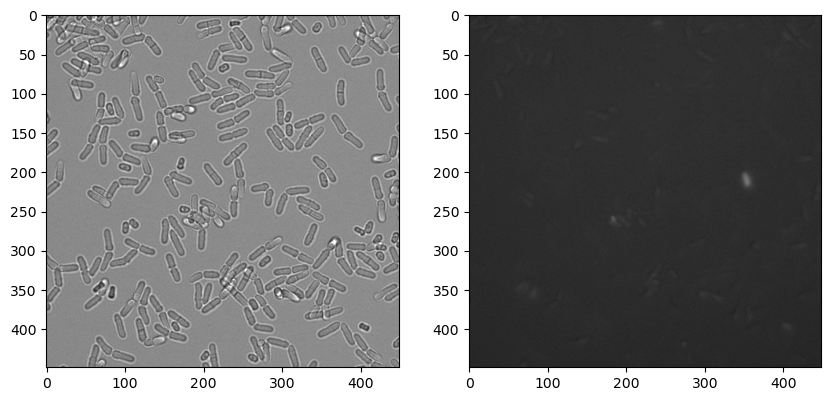

In [ ]:
pixel_ranges = {'EMM': 
                    {'bf': (0,3000),
                     'gfp': (1500,4000)},
                'YES': 
                    {'bf': (0,3000),
                     'gfp': (1500,8000)
                     } 
                }

images = {'bf': img_bf, 
          'gfp': img_gfp}

location = (451,900,451,900)

fig, axarr = plt.subplots(1,2, figsize=(10,5))

for jj, (channel, img) in enumerate(images.items()):
    ax = axarr[jj]
    pixel_range = pixel_ranges[media][channel]
    ax.imshow(img[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=pixel_range[0], vmax = pixel_range[1])
    #ax.imshow(img[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=black_value, vmax = white_value)
        
    

In [ ]:
EMM_background = 

In [ ]:
#First Plot:  

#Promoter causes increase in GFP expression (both backgrounds) (only YES)


#Second Plot (one for each background): 
#NMT1 and RPL2102 driving Mbx2 shows an increase in clumpiness in appropriate media (YES + EMM).  

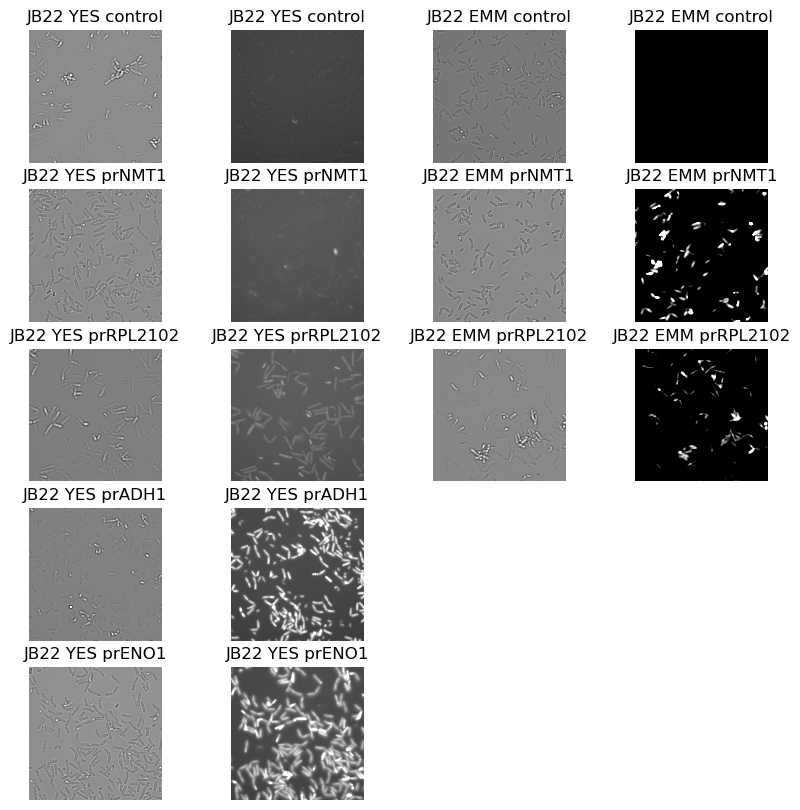

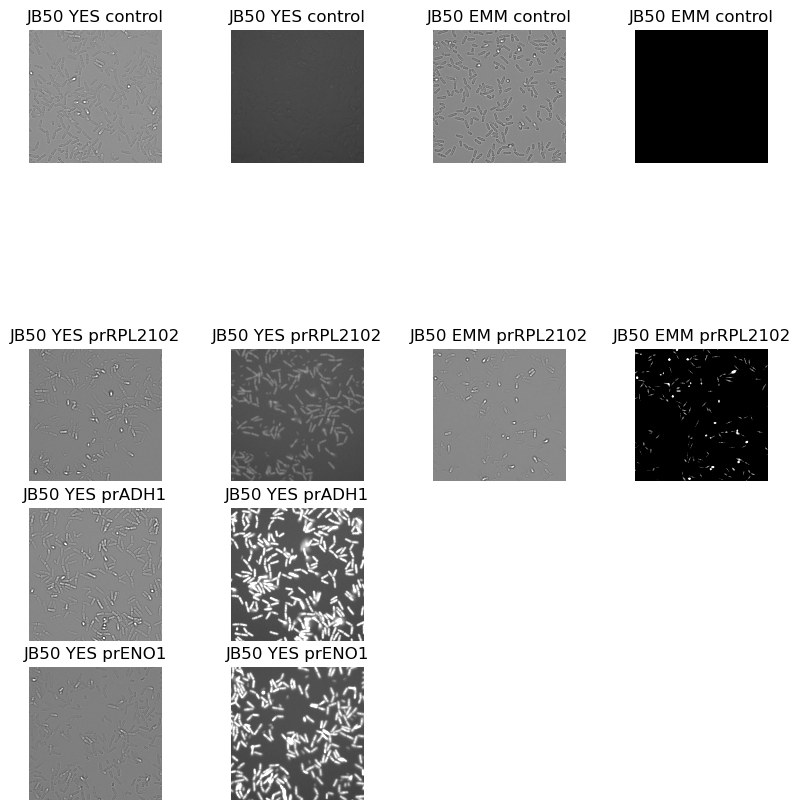

In [ ]:
#GFP expression under different promoters

promoters = ['control','prNMT1', 'prRPL2102', 'prADH1', 'prENO1']
backgrounds = ['JB22', 'JB50']
media = ['YES', 'EMM']

oe_gene = "GFP"

pixel_ranges = {'EMM': 
                    {'bf': (0,3000),
                     'gfp': (1500,3000)},
                'YES': 
                    {'bf': (0,3000),
                     'gfp': (1500,5000)
                     } 
                }

location = (451,900,451,900)


#Subtract Background from GFP images?
background


for ii, background in enumerate(backgrounds):   
    fig, axarr = plt.subplots( len(promoters),len(media)*2, figsize=(10,10))
    for jj, medium in enumerate(media):
        for kk, promoter in enumerate(promoters):
            
            if promoter == 'control':
                strain_id = background
                img_fname = image_dir + os.sep + os.path.normpath(medium + '_plate_tiff_images/' + background + '_control_control_' + strain_id + '_BR1_TR1.tif')
            else: 
                strain_id = strain_ids[(background,promoter,oe_gene)]   
                if (strain_id is None) or (strain_id in {'LS15','LS16', 'LS09','LS10'} and medium == 'EMM'):
                    ax = axarr[kk, jj*2]
                    ax.axis('off')

                    ax = axarr[kk, jj*2+1]
                    ax.axis('off')
                    continue
                
                img_fname = image_dir + os.sep + os.path.normpath(medium + '_plate_tiff_images/' + background + '_' + promoter + '_' + oe_gene + '_' + strain_id + '_BR1_TR1.tif')
                  
            img = ski.io.imread(img_fname)
            
            img_bf = img[0,:,:]           
            pixel_range = pixel_ranges[medium]['bf']
            ax = axarr[kk, jj*2]
            ax.imshow(img_bf[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=pixel_range[0], vmax = pixel_range[1])
            ax.set_title(background + ' ' + medium + ' ' + promoter)
            ax.axis('off')    

            img_gfp = img[1,:,:]
            pixel_range = pixel_ranges[medium]['gfp']
            ax = axarr[kk, jj*2+1]
            ax.imshow(img_gfp[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=pixel_range[0], vmax = pixel_range[1])
            ax.set_title(background + ' ' + medium + ' ' + promoter)
            ax.axis('off')       

            


prNMT1 GFP YES JB22 LS13
1
prNMT1 mbx2 YES JB22 LS19
2
prRPL2102 GFP YES JB22 LS14
3
prRPL2102 mbx2 YES JB22 LS20
4
prNMT1 GFP EMM JB22 LS13
1
prNMT1 mbx2 EMM JB22 LS19
2
prRPL2102 GFP EMM JB22 LS14
3
prRPL2102 mbx2 EMM JB22 LS20
4
prNMT1 mbx2 YES JB50 LS17
2
prRPL2102 GFP YES JB50 LS08
3
prRPL2102 mbx2 YES JB50 LS18
4
prNMT1 mbx2 EMM JB50 LS17
2
prRPL2102 GFP EMM JB50 LS08
3
prRPL2102 mbx2 EMM JB50 LS18
4


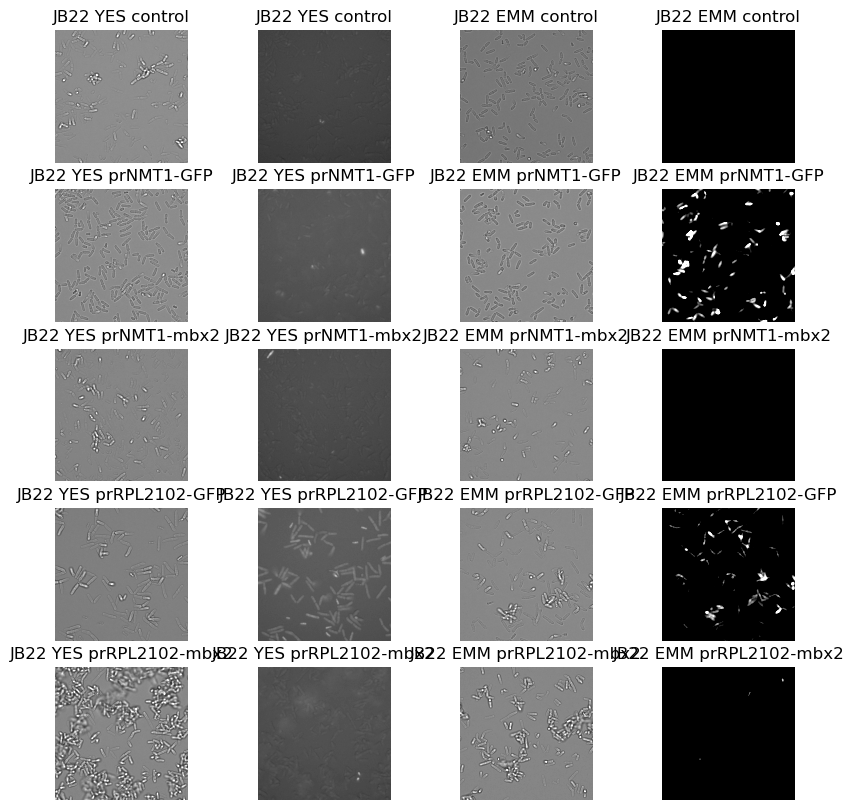

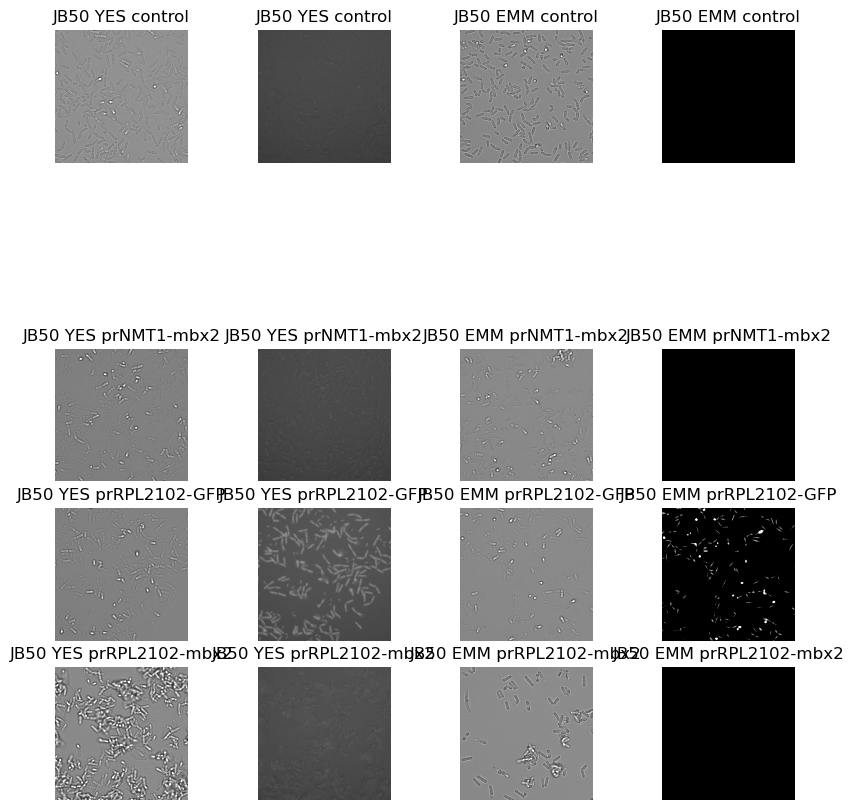

In [9]:
#Plot cells overexpressing Mbx2

promoters = ['prNMT1', 'prRPL2102']
oe_genes = ['GFP', 'mbx2']
backgrounds = ['JB22', 'JB50']
media = ['YES', 'EMM']


pixel_ranges = {'EMM': 
                    {'bf': (0,3000),
                     'gfp': (1500,3000)},
                'YES': 
                    {'bf': (0,3000),
                     'gfp': (1500,5000)
                     } 
                }

location = (451,900,451,900)


#Subtract Background from GFP images?

#Plot Control in the first row and 3rd row


for ii, background in enumerate(backgrounds):   
    fig, axarr = plt.subplots( (len(promoters))*len(oe_genes) + 1 ,len(media)*2, figsize=(10,10))
    for jj, medium in enumerate(media):

        #Control image in first row
        strain_id = background
        img_fname = image_dir + os.sep + os.path.normpath(medium + '_plate_tiff_images/' + background + '_control_control_' + strain_id + '_BR1_TR1.tif')

        img = ski.io.imread(img_fname)

        ax = axarr[0, jj*2]  #Control Bright field    
        img_bf = img[0,:,:]           
        pixel_range = pixel_ranges[medium]['bf']
        ax.imshow(img_bf[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=pixel_range[0], vmax = pixel_range[1])
        ax.set_title(background + ' ' + medium + ' control')
        ax.axis('off')    

        ax = axarr[0, jj*2+1]  #Control GFP
        img_gfp = img[1,:,:]
        pixel_range = pixel_ranges[medium]['gfp']
        ax.imshow(img_gfp[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=pixel_range[0], vmax = pixel_range[1])
        ax.set_title(background + ' ' + medium + ' control')
        ax.axis('off')     

        for kk, promoter in enumerate(promoters):
           for ll, oe_gene in enumerate(oe_genes): 
 
            strain_id = strain_ids[(background,promoter,oe_gene)]   
            if (strain_id is None) or (strain_id in {'LS15','LS16', 'LS09','LS10'} and medium == 'EMM'):
                ax = axarr[1 + ll + 2*kk, jj*2]
                ax.axis('off')

                ax = axarr[1 + ll + 2*kk, jj*2+1]
                ax.axis('off')
                continue
            
            img_fname = image_dir + os.sep + os.path.normpath(medium + '_plate_tiff_images/' + background + '_' + promoter + '_' + oe_gene + '_' + strain_id + '_BR1_TR1.tif')
                  
            img = ski.io.imread(img_fname)
            
            print( promoter + ' ' + oe_gene + ' ' + medium + ' ' + background + ' ' + strain_id)
            print(str(1 + ll + 2*kk))

            ax = axarr[1 + ll + 2*kk, jj*2]  #Bright field
            img_bf = img[0,:,:]           
            pixel_range = pixel_ranges[medium]['bf']
            ax.imshow(img_bf[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=pixel_range[0], vmax = pixel_range[1])
            ax.set_title(background + ' ' + medium + ' ' + promoter + '-' + oe_gene)
            ax.axis('off')    

            ax = axarr[1 + ll + 2*kk, jj*2 + 1]  #GFP
            img_gfp = img[1,:,:]
            pixel_range = pixel_ranges[medium]['gfp']
            ax.imshow(img_gfp[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=pixel_range[0], vmax = pixel_range[1])
            ax.set_title(background + ' ' + medium + ' ' + promoter + '-' + oe_gene)
            ax.axis('off')      


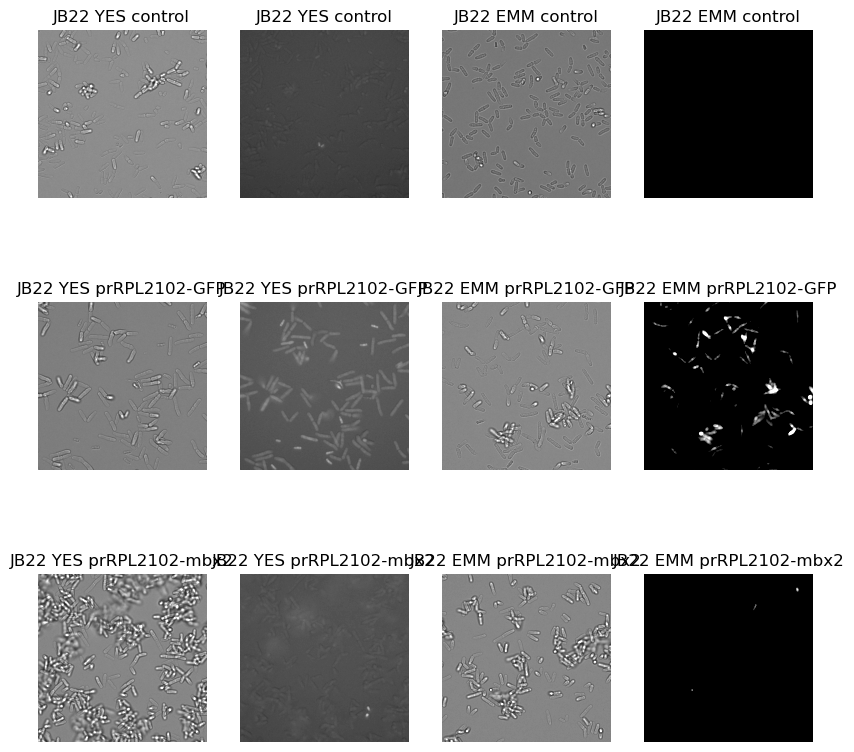

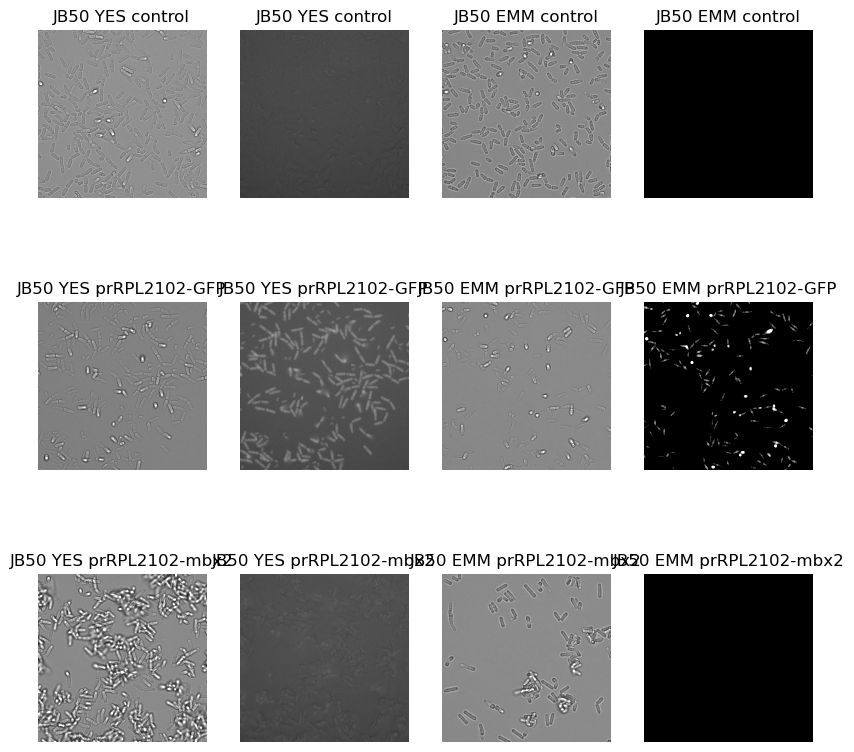

In [6]:
#Plot cells overexpressing Mbx2

promoters = ['prRPL2102']
oe_genes = ['GFP', 'mbx2']
backgrounds = ['JB22', 'JB50']
media = ['YES', 'EMM']


pixel_ranges = {'EMM': 
                    {'bf': (0,3000),
                     'gfp': (1500,3000)},
                'YES': 
                    {'bf': (0,3000),
                     'gfp': (1500,5000)
                     } 
                }

location = (451,900,451,900)


#Subtract Background from GFP images?

#Plot Control in the first row and 3rd row


for ii, background in enumerate(backgrounds):   
    fig, axarr = plt.subplots( (len(promoters))*len(oe_genes) + 1 ,len(media)*2, figsize=(10,10))
    for jj, medium in enumerate(media):

        #Control image in first row
        strain_id = background
        img_fname = image_dir + os.sep + os.path.normpath(medium + '_plate_tiff_images/' + background + '_control_control_' + strain_id + '_BR1_TR1.tif')

        img = ski.io.imread(img_fname)

        ax = axarr[0, jj*2]  #Control Bright field    
        img_bf = img[0,:,:]           
        pixel_range = pixel_ranges[medium]['bf']
        ax.imshow(img_bf[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=pixel_range[0], vmax = pixel_range[1])
        ax.set_title(background + ' ' + medium + ' control')
        ax.axis('off')    

        ax = axarr[0, jj*2+1]  #Control GFP
        img_gfp = img[1,:,:]
        pixel_range = pixel_ranges[medium]['gfp']
        ax.imshow(img_gfp[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=pixel_range[0], vmax = pixel_range[1])
        ax.set_title(background + ' ' + medium + ' control')
        ax.axis('off')     

        for kk, promoter in enumerate(promoters):
           for ll, oe_gene in enumerate(oe_genes): 
 
            strain_id = strain_ids[(background,promoter,oe_gene)]   
            if (strain_id is None) or (strain_id in {'LS15','LS16', 'LS09','LS10'} and medium == 'EMM'):
                ax = axarr[1 + ll + 2*kk, jj*2]
                ax.axis('off')

                ax = axarr[1 + ll + 2*kk, jj*2+1]
                ax.axis('off')
                continue
            
            img_fname = image_dir + os.sep + os.path.normpath(medium + '_plate_tiff_images/' + background + '_' + promoter + '_' + oe_gene + '_' + strain_id + '_BR1_TR1.tif')
                  
            img = ski.io.imread(img_fname)

            ax = axarr[1 + ll + 2*kk, jj*2]  #Bright field
            img_bf = img[0,:,:]           
            pixel_range = pixel_ranges[medium]['bf']
            ax.imshow(img_bf[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=pixel_range[0], vmax = pixel_range[1])
            ax.set_title(background + ' ' + medium + ' ' + promoter + '-' + oe_gene)
            ax.axis('off')    

            ax = axarr[1 + ll + 2*kk, jj*2 + 1]  #GFP
            img_gfp = img[1,:,:]
            pixel_range = pixel_ranges[medium]['gfp']
            ax.imshow(img_gfp[location[0]:location[1],location[2]:location[3]], cmap = plt.cm.gray, vmin=pixel_range[0], vmax = pixel_range[1])
            ax.set_title(background + ' ' + medium + ' ' + promoter + '-' + oe_gene)
            ax.axis('off')      

    fig.savefig(image_dir + os.sep + os.path.normpath('rpl2102_' + background + '_raw.svg'))

## Visualization of Adhesion Experiment


In [ ]:
#Visualize Adhesion Experiment.  
# Original data at 
#G:\.shortcut-targets-by-id\1f06Ul9xUBz8egM88xR3jbhhDGFyt8uLu\S.-Pombe-MLPs\revisions_data\20251003_mbx2_oe_adhesion_assay\
# Bence Processed the data and put it into spreadsheets in the results folder

